# Statistical significance of trained ML models
The primary focus of this notebook is to evaluate the dependance of ML models on L96 simulation length and number of epochs. I will especially emphesize statistical significance of trained models

In [1]:
import numpy as np
from parameterizations import *
from util import *
import matplotlib.pyplot as plt
import pickle
import os
import re
from L96 import L962LvlMem

In [18]:
# Training data files
files = os.listdir('online_runs/NO_PARAMETRIZATION')
files.sort()
files

['time=10000000_m=0.001_tau=0.001.pkl',
 'time=10000000_m=0.0021544346900318843_tau=0.003593813663804626.pkl',
 'time=10000000_m=0.004641588833612777_tau=0.01291549665014884.pkl',
 'time=10000000_m=0.01_tau=0.046415888336127795.pkl',
 'time=10000000_m=0.021544346900318832_tau=0.1668100537200059.pkl',
 'time=10000000_m=0.046415888336127774_tau=0.5994842503189409.pkl',
 'time=10000000_m=0.1_tau=2.1544346900318843.pkl',
 'time=10000000_m=0.21544346900318823_tau=7.742636826811277.pkl',
 'time=10000000_m=0.46415888336127775_tau=27.825594022071257.pkl',
 'time=500000_m=0.001_tau=0.001.pkl']

In [3]:
# Load training data
path = 'online_runs/NO_PARAMETRIZATION/' + files[0]
with open(path, 'rb') as file:
        L96 = pickle.load(file)
        
m = float(re.search(r'm=([\d.]+)', path).group(1))
tau = float(re.search(r'tau=([\d.]+)', path).group(1)[:-1])

In [4]:
# Create a subset of the L96 object 
Nt = 1000 * 1000
L96_subset = L962LvlMem(m=m, tau=tau)
L96_subset._history_X = L96._history_X[:Nt]
L96_subset._history_B = L96._history_B[:Nt]

Memory steps: 1


In [5]:
# Transoform data
past_timesteps = 1000
X_train, X_test, B_train, B_test = generate_data(L96_subset, past_timesteps=past_timesteps)

In [9]:
Ne = 10_000
model_ae_1 = NNpAE(past_timesteps, latent_dims=1)
train_model(X_train, X_test, B_train, B_test, model=model_ae_1, num_epochs=Ne)

#model_ae_3 = NNpAE(past_timesteps, latent_dims=3)
#train_model(X_train, X_test, B_train, B_test, model=model_ae_3, num_epochs=Ne)

#model_ae_5 = NNpAE(past_timesteps, latent_dims=5)
#train_model(X_train, X_test, B_train, B_test, model=model_ae_5, num_epochs=Ne)

#model_ae_10 = NNpAE(past_timesteps, latent_dims=10)
#train_model(X_train, X_test, B_train, B_test, model=model_ae_10, num_epochs=Ne)
pass

0.007


Training: 100%|██████████████████████████| 10000/10000 [23:46<00:00,  7.01it/s, Train Loss=1.3019, Test Loss=1.3092, R²=0.9376, Best R²=0.9385 @ 9973]


In [17]:
5 * 3 * 10

150

(0.0, 2000.0)

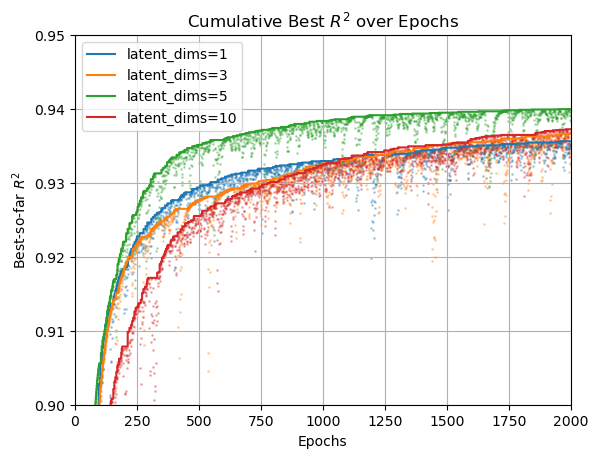

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# List of models
models = [model_ae_1, model_ae_3, model_ae_5, model_ae_10]

for model in models:
    R2 = np.array([x.cpu() for x in model.R2])
    R2_cummax = np.maximum.accumulate(R2)  # Cumulative maximum
    epochs = np.arange(1, len(R2) + 1)
    plt.scatter(epochs, R2, s=1, alpha=.3)
    plt.step(epochs, R2_cummax, label=f'latent_dims={model.latent_dims}')

plt.ylim(0.9, 0.95)
plt.xlabel('Epochs')
plt.ylabel('Best-so-far $R^2$')
plt.title('Cumulative Best $R^2$ over Epochs')
plt.legend()
plt.grid(True)
plt.xlim(0, 2000)

In [8]:
for model in [model_ae_1, model_ae_3, model_ae_5, model_ae_10]:
    save_model(model)

In [ ]:
Ne = 10_000
model_ae = NNpAE(past_timesteps, latent_dims=3)
train_model(X_train, X_test, B_train, B_test, model=model_ae, num_epochs=Ne);

Training: 100%|█████████████████████████| 20000/20000 [05:54<00:00, 56.47it/s, Train Loss=1.1646, Test Loss=1.3252, R²=0.9358, Best R²=0.9373 @ 11840]
